In [2]:
import numpy as np
import matplotlib.pyplot as plt

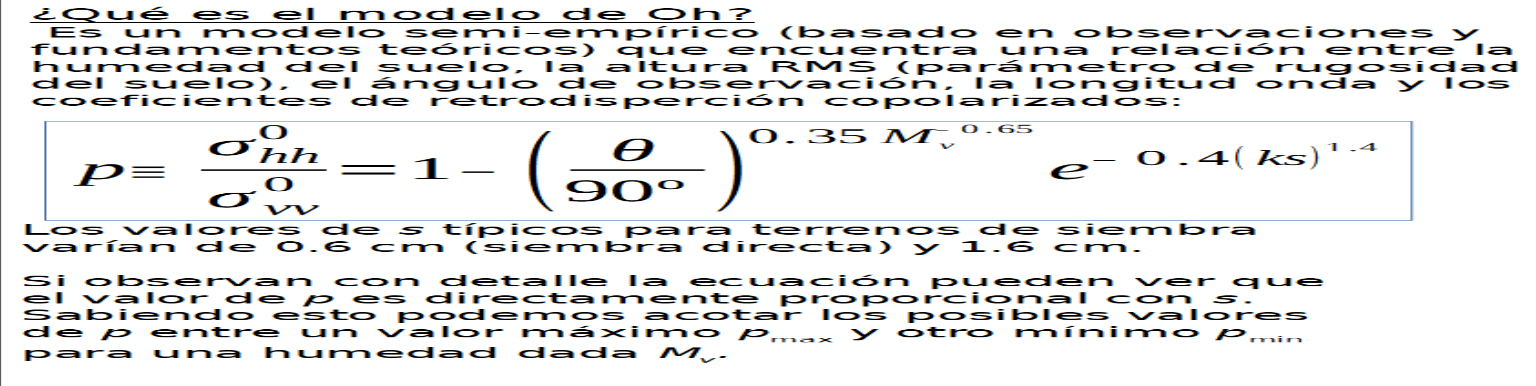

In [12]:
def oh_model(theta, mv, lmb, s):
    return (
        1
        - (theta / 90) ** (0.35 * mv ** (-0.65))
        * 10 ** (-0.4 * ((2 * np.pi / lmb) * s) ** 1.4)
    )

In [17]:
THETA = 19
LAMBDA = 5 # Banda C
MV = np.arange(0.05, 0.80, 0.005)

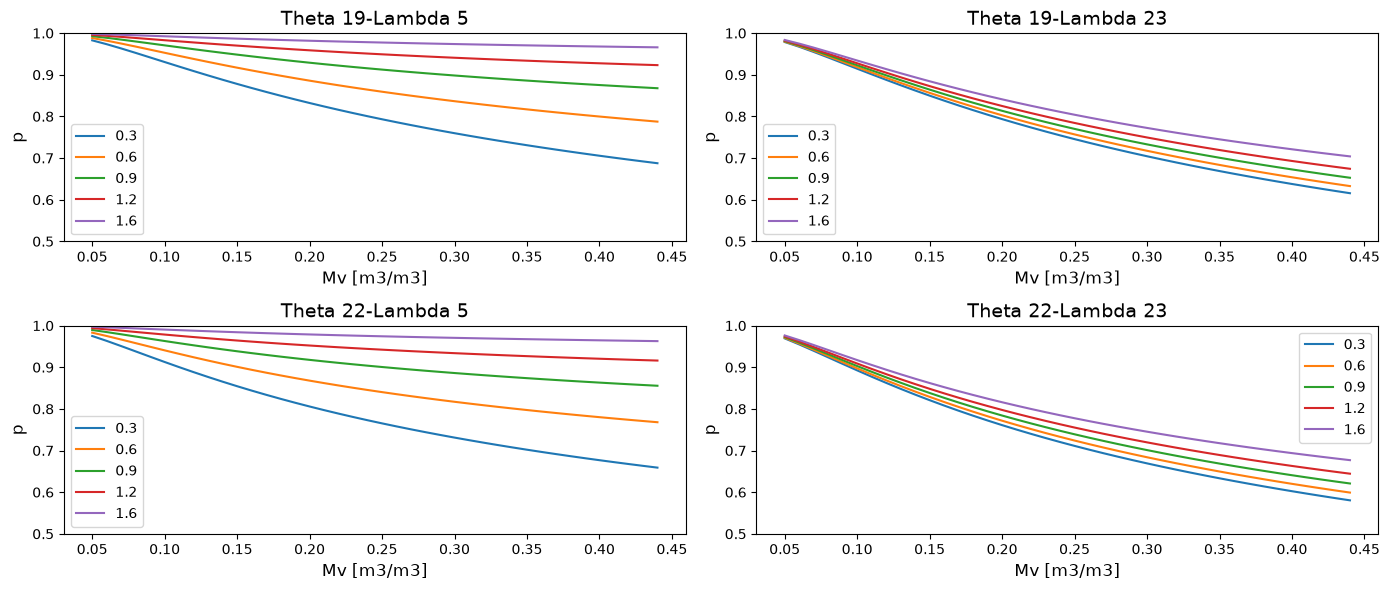

In [37]:
list_s = [0.3, 0.6, 0.9, 1.2, 1.6]
list_theta = [19, 22]
list_lambda = [5, 23]
MV = np.arange(0.05, 0.45, 0.01)

fig, ax = plt.subplots(2, 2, figsize=(14, 6), tight_layout=True)
#ax = ax.ravel()

for i, t in enumerate(list_theta):
    #print(i)
    for j, l in enumerate(list_lambda):
        for s in list_s:
            #print(t, l, s)
            ax[i, j].plot(MV, oh_model(t, MV, l, np.full(len(MV), s)), label=s)

        ax[i, j].set_title(f'Theta {t}-Lambda {l}', fontsize=14)
        ax[i, j].legend(loc='best')
        ax[i, j].set_xlabel('Mv [m3/m3]', fontsize=12)
        ax[i, j].set_ylabel('p', fontsize=12)
        ax[i, j].set_ylim(0.5, 1)


In [ ]:
!git clone https://github.com/robbiemallett/IIEM.git
# https://github.com/robbiemallett/IIEM

pip install mpmath

Cloning into 'IIEM'...
remote: Enumerating objects: 20, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 20 (delta 0), reused 0 (delta 0), pack-reused 17 (from 1)
Receiving objects: 100% (20/20), 10.81 KiB | 5.40 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [1]:
import sys
sys.path.append('IIEM')

from I2EM import backscatter

In [2]:
from I2EM import backscatter

In [ ]:
C = 2.998e+10 # cm/s
LAMBDA = 5 # cm
#SIGMA = None
FR = C/LAMBDA/1e9 # GHz
L = 10 # cm; java implementation
SIGMA = 1.05 # S param; cm; java implementation

In [3]:
import numpy as np


def moisture_to_complex_dielectric(
    mv, freq_hz, bulk_cond_s_m = 0.01
) -> complex:
    """Calculates the complex dielectric constant from volumetric moisture content (m3/m3).

    :param theta: Volumetric water content in m3/m3 (e.g., 0.15 for 15%)
    :param freq_hz: Measurement frequency in Hz (default: 50 MHz)
    :param bulk_cond_s_m: Bulk ionic conductivity in S/m (default: 0.01 S/m)
    :return: Complex dielectric constant (er)
    """
    # 1. Real part (Storage): Topp's Polynomial Equation
    e_real = 3.03 + (9.3 * mv) + (146.0 * (mv**2)) - (76.7 * (mv**3))

    # 2. Imaginary part (Loss): Dielectric loss dominated by DC conductivity
    e_0 = 8.8541878128e-12  # Permittivity of free space (F/m)
    e_imag = bulk_cond_s_m / (2 * np.pi * freq_hz * e_0)

    # 3. Express as complex number: er = e' - j*e''
    er = complex(e_real, e_imag)

    return er


'''# Example usage:
mv = 0  # 0.15 m3/m3 moisture content
er = moisture_to_complex_dielectric(mv, FR*1e9)

print(f"Moisture Content: {mv} m3/m3")
print(f"Complex Dielectric Constant (er): {er}")'''

'# Example usage:\nmv = 0  # 0.15 m3/m3 moisture content\ner = moisture_to_complex_dielectric(mv, FR*1e9)\n\nprint(f"Moisture Content: {mv} m3/m3")\nprint(f"Complex Dielectric Constant (er): {er}")'

In [8]:
# --
C = 2.998e+10 # cm/s
LAMBDA = 5 # cm
FR = 5.405#C/LAMBDA/1e9 # GHz


# --
for mv in MV:
    #print(mv)
    er=moisture_to_complex_dielectric(mv, FR*1e9, bulk_cond_s_m = 0.01)
    #print(er.real)
    

In [4]:
sigma_0_vv, sigma_0_hh = backscatter(
    frequency=FR,       # GHz — e.g., Sentinel-1 C-band
    sig=SIGMA/100,               # rms height of surface, in meters
    L=L/100,                 # correlation length, in meters
    thi=35,                 # incidence angle, in degrees
    er=complex(3, 0.05),     # dielectric constant (complex number)
    sp='exponential',       # surface correlation function type
    xx=1.5,                 # only used if sp == 'power_spec'; can be arbitrary otherwise
    block_crosspol=False,   # set True to skip the (slower) cross-pol calc
)


'''
er = complex(3, 0.05) — Multiple independent sources converge on this range for dry soil: the real part of the dielectric constant is about 2 to 4 and the imaginary part is about 0.05, and separately, the dielectric constant of dry soils is generally in the range of 2.5 to 4.0. Another source specifically comparing dry vs. wet conditions notes dry soil has a dielectric constant of approximately 2-3, compared to approximately 81 for water. So complex(3, 0.05) sits right in the middle of the consensus dry-soil range — a low real part (little contrast with air, low permittivity) and a very small imaginary part (low dielectric loss, since dry soil barely absorbs the microwave signal). Feel free to nudge the real part anywhere between 2.5–4 depending on exact soil texture/mineralogy if you have more specific data. 
Effects of Soil Properties on Microwave Dielectric Constants +2

sp='exponential' — this is the standard/most common correlation function used for bare soil surfaces in IEM-family models (vs. 'gaussian', which tends to better represent smoother, more "wavy" surfaces like some vegetation canopies or certain agricultural tillage patterns). Since you're modeling bare soil roughness, 'exponential' is the right default — this is your setting to keep as-is.

xx=1.5 — irrelevant here since it's only used when sp == 'power_spec'; leave it at any placeholder value.

block_crosspol=False — keep cross-pol on if you need VH/HV output for classification or soil-moisture-vs-roughness disambiguation; set True if you only care about VV/HH and want faster execution (cross-pol involves an extra, slower dblquad).
'''

print("VV:", sigma_0_vv, "dB")
print("HH:", sigma_0_hh, "dB")
#print("HV:", sigma_0_hv, "dB")

VV: -12.109499522856815 dB
HH: -15.675795786310347 dB


In [23]:
C = 2.998e+10 # cm/s
LAMBDA = 5 # cm
FR = 5.405#C/LAMBDA/1e9 # GHz
THETA = 19
S = 0.3 # SIGMA ~ RMS; cm
L = 10 # cm; java implementation

In [24]:
list_p_iem = []

for mv in MV:
    
    sigma_0_vv, sigma_0_hh = backscatter(
        frequency=FR,       # GHz — e.g., Sentinel-1 C-band
        sig=S/100,               # rms height of surface, in meters
        L=L/100,                 # correlation length, in meters
        thi=THETA,                 # incidence angle, in degrees
        er=moisture_to_complex_dielectric(mv, FR*1e9, bulk_cond_s_m = 0.01),     # dielectric constant (complex number)
        sp='exponential',       # surface correlation function type
        xx=1.5,                 # only used if sp == 'power_spec'; can be arbitrary otherwise
        block_crosspol=False,   # set True to skip the (slower) cross-pol calc
    )
    
    list_p_iem.append(10**(sigma_0_hh/10)/10**(sigma_0_vv/10))

Text(0.5, 0, 'IEM model')

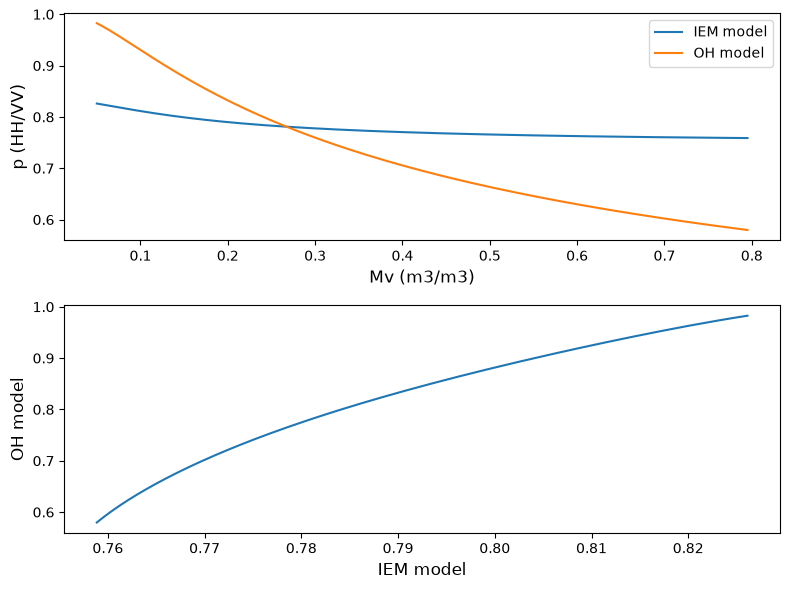

In [25]:
fig, ax = plt.subplots(2, 1, figsize=(8, 6), tight_layout=True)

ax[0].plot(MV, np.array(list_p_iem), label='IEM model')
ax[0].plot(MV, oh_model(THETA, MV, LAMBDA, np.full(len(MV), S)), label='OH model')
ax[0].legend(loc='best')
ax[0].set_ylabel('p (HH/VV)', fontsize=12)
ax[0].set_xlabel('Mv (m3/m3)', fontsize=12)

ax[1].plot(np.array(list_p_iem), oh_model(THETA, MV, LAMBDA, np.full(len(MV), S)))
ax[1].set_ylabel('OH model', fontsize=12)
ax[1].set_xlabel('IEM model', fontsize=12)

